Preprocessing

In [44]:
import pandas as pd  
import numpy as np


In [45]:
Data = pd.read_csv("adults.csv")


y_raw = Data['hours-per-week']
x_raw = Data
x_raw.drop('education-num', axis=1, inplace=True)
x_raw.drop('income', axis=1, inplace=True)
print(x_raw.shape)
print(y_raw.shape)


(48842, 13)
(48842,)


In [46]:
# x_raw = x_raw.replace("?", np.nan)
# x_raw[pd.isnull(x_raw).any(axis=1)].shape
# rows_with_missing_values = x_raw[pd.isnull(x_raw).any(axis=1)]

# x_raw.dropna(inplace=True)
# x_raw.drop('education-num', axis=1, inplace=True)
# y_raw = y_raw.drop(rows_with_missing_values.index)


In [47]:
# x = pd.DataFrame(x_raw)
# y = pd.DataFrame(y_raw)
# x_names = x.columns.tolist()
# x_names = np.array(x_names)
# y_names = y.columns.tolist()
x = x_raw
y = y_raw

In [48]:
#print(x[10:60])
print(x['workclass'][x['workclass'] == '?'])

x['workclass'], value = pd.factorize(x_raw['workclass'])
print("1",value)
x['education'], value = pd.factorize(x_raw['education'])
print("2",value)
x['marital-status'], value = pd.factorize(x_raw['marital-status'])
print("3",value)
x['occupation'], value = pd.factorize(x_raw['occupation'])
print("4",value)
x['relationship'], value = pd.factorize(x_raw['relationship'])
print("5",value)
x['race'], value = pd.factorize(x_raw['race'])
print("6",value)
x['sex'], value = pd.factorize(x_raw['sex'])
print("7",value)
x['native-country'], value = pd.factorize(x_raw['native-country'])
print("9",value)


#print(x)

Series([], Name: workclass, dtype: object)
1 Index([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay', ' Never-worked'],
      dtype='object')
2 Index([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th', ' Some-college',
       ' Assoc-acdm', ' Assoc-voc', ' 7th-8th', ' Doctorate', ' Prof-school',
       ' 5th-6th', ' 10th', ' 1st-4th', ' Preschool', ' 12th'],
      dtype='object')
3 Index([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'],
      dtype='object')
4 Index([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'],
      dtype='object')
5 Index([' Not-in-family', ' Husband', '

In [49]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x['age'] = scaler.fit_transform(x[['age']])
x['fnlwgt'] = scaler.fit_transform(x[['fnlwgt']])
x['capital-gain'] = scaler.fit_transform(x[['capital-gain']])
x['capital-loss'] = scaler.fit_transform(x[['capital-loss']])

# 將陣列 reshape 成一列
y = scaler.fit_transform(y.values.reshape(-1, 1))

print(y)


[[0.39795918]
 [0.12244898]
 [0.39795918]
 ...
 [0.5       ]
 [0.39795918]
 [0.60204082]]


In [50]:
# x = x.to_numpy()
# y = y.to_numpy()



KNN

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)
x_train, x_valid, y_train, y_valid = train_test_split(x_train,y_train,test_size=0.2)

In [52]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

#從k值=1開始測試
mape = []
rmse = []
r2 = []

for i in range(1,61):
    
    model = KNeighborsRegressor(n_neighbors=i, n_jobs=-1)
    model.fit(x_train,y_train.ravel())

    pred_test = model.predict(x_test)

    # print("Test Score:")
    mape.append(mean_absolute_percentage_error(y_test, pred_test))
    rmse.append(mean_squared_error(y_test, pred_test, squared=False))
    r2.append(r2_score(y_test, pred_test))

    index = np.argmax(r2)
    best_pred = pred_test
    if (i%10) == 0: print(i,"/ 60")

print("Mean Absolute Percentage Error:", np.min(mape),"K value = ",np.argmin(mape))
print("Root Mean Squared Error:", np.min(rmse), "K value = ",np.argmin(rmse))
print("R2 Score:", np.max(r2), "K value = ",np.argmax(r2))

10 / 100
20 / 100
30 / 100
40 / 100
50 / 100
Mean Absolute Percentage Error: 31362245436.758713 K value =  0
Root Mean Squared Error: 0.003868991930427592 K value =  3
R2 Score: 0.9990506284257533 K value =  3


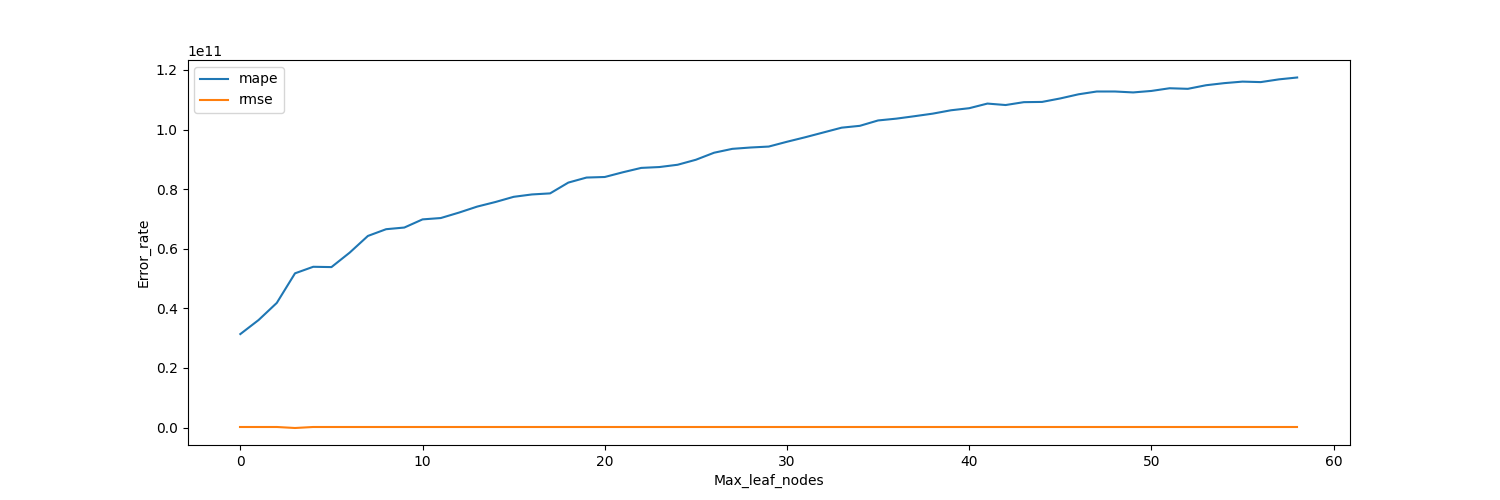

In [53]:
import matplotlib.pyplot as plt
%matplotlib widget
fig = plt.figure(figsize=(15,5))
plt.xlabel('Max_leaf_nodes')
plt.ylabel("Error_rate")
plt.plot(mape, label='mape')
plt.plot(rmse, label='rmse')
#plt.plot(mean_r2, label='r2')
plt.legend()
plt.show()

0.5 [0.5]
0.4446558284330682 [0.43877551]
0.3979591836734693 [0.39795918]
0.297820823244552 [0.29591837]
0.29574541681079214 [0.29591837]
0.6023867173988237 [0.60204082]
0.3979591836734693 [0.39795918]
0.3979591836734693 [0.39795918]
0.3981321342096159 [0.39795918]
0.3979591836734693 [0.39795918]
0.07367692839847802 [0.07142857]
0.3979591836734693 [0.39795918]
0.39778623313732264 [0.39795918]
0.5 [0.5]
0.4975786924939468 [0.5]
0.3986509858180559 [0.39795918]
0.3977862331373226 [0.39795918]
0.3979591836734693 [0.39795918]
0.30716015219647175 [0.29591837]
0.3979591836734693 [0.39795918]
0.39086821169145614 [0.37755102]
0.3976132826011759 [0.39795918]
0.3981321342096159 [0.39795918]
0.3478035281909373 [0.34693878]
0.3313732272570044 [0.32653061]
0.550674507090972 [0.55102041]
0.19387755102040813 [0.19387755]
0.3979591836734693 [0.39795918]
0.2981667243168454 [0.29591837]
0.3516084399861638 [0.34693878]
0.4993081978554133 [0.5]
0.3919059149083361 [0.37755102]
0.3979591836734693 [0.39795918

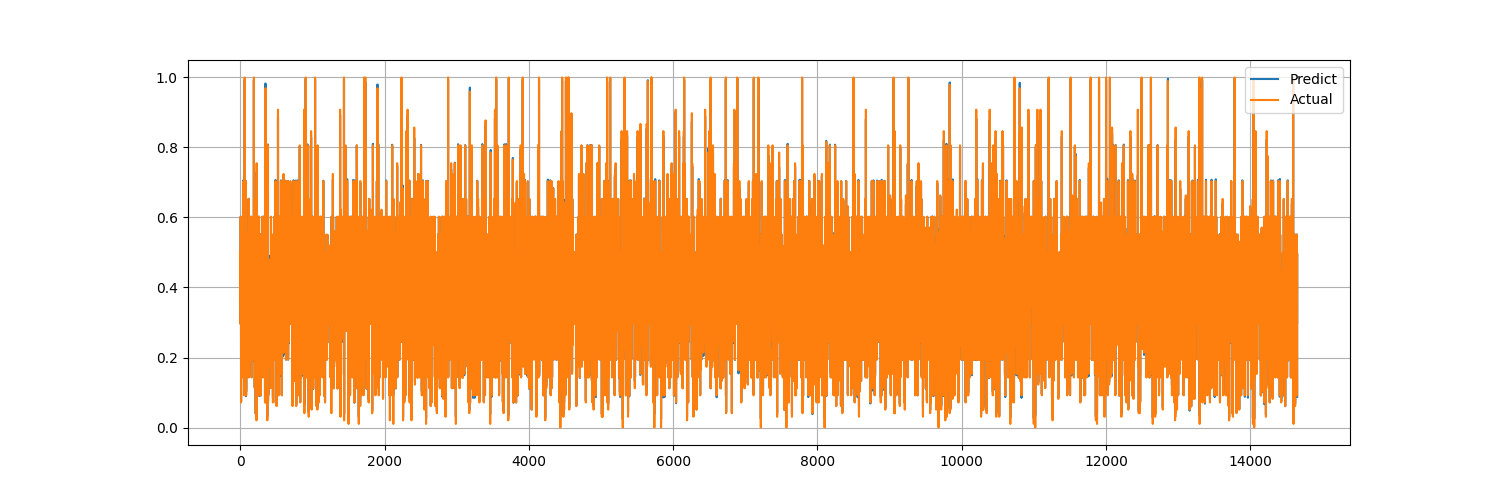

In [54]:
%matplotlib widget
import matplotlib.pyplot as plt

for i in range(len(y_test)):
    print(pred_test[i],y_test[i])

fig = plt.figure(figsize=(15,5))
plt.plot(best_pred,label = 'Predict')
plt.plot(np.array(y_test),label = 'Actual')
plt.grid()
plt.legend()
plt.show()